# 신용카드 채무불이행 고객 예측 -

https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset

In [3]:
# !pip install xlrd --break-system-packages


# 전체 작업 순서

0. **데이터 로딩 (Data Loading)**  
1. **데이터 이해 (Data Understanding)**  
2. **EDA (탐색적 데이터 분석)**  
3. **데이터 전처리 (Data Preprocessing)**  
4. **데이터 분할 (Train / Test Split)**  
5. **Baseline 모델 구축**  
6. **모델 비교 (Model Selection)**  
7. **평가 지표 설정 (Evaluation Metrics)**  
8. **교차 검증 (Cross Validation)**  
9. **하이퍼파라미터 튜닝 (Hyperparameter Tuning)**  
10. **Feature Importance 분석**  
11. **최종 모델 선택 및 평가**

# 0. 데이터 로딩

## Library Loading

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# 그래프 기본 스타일
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style="whitegrid")

# 경고 메시지 숨기기(선택)
import warnings
warnings.filterwarnings("ignore")

## 데이터 로딩

In [2]:
import pandas as pd
import urllib.request
import os

os.makedirs('./data', exist_ok=True)

# UCI 원본
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls"
urllib.request.urlretrieve(url, './data/UCI_Credit_Card.xls')

# xls 읽기
org_df = pd.read_excel('./data/UCI_Credit_Card.xls', header=1)
org_df.to_csv('./data/UCI_Credit_Card_1.csv', index=False)

card_df = org_df.copy()
print(org_df.shape)

(30000, 25)


# 1.Data 이해 및 EDA (Exploratory Data Analysis)

## EDA 작업 순서
1. 데이터 크기 / head / info
2. 타깃 분포 확인
3. 결측치 / 중복 확인
4. 범주형 변수 분포 확인
5. 수치형 변수 분포 및 이상치 확인
6. 타깃과 변수 관계 확인
7. 상관관계 확인
8. 모델링 시사점 정리

## 1.3 데이터 확인/조사

In [3]:
org_df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [4]:
org_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_AMT3        

In [5]:
display(org_df.describe())

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


## 1.4 타깃 변수 분포 확인

default payment next month
0    23364
1     6636
Name: count, dtype: int64

default payment next month
0    0.7788
1    0.2212
Name: proportion, dtype: float64


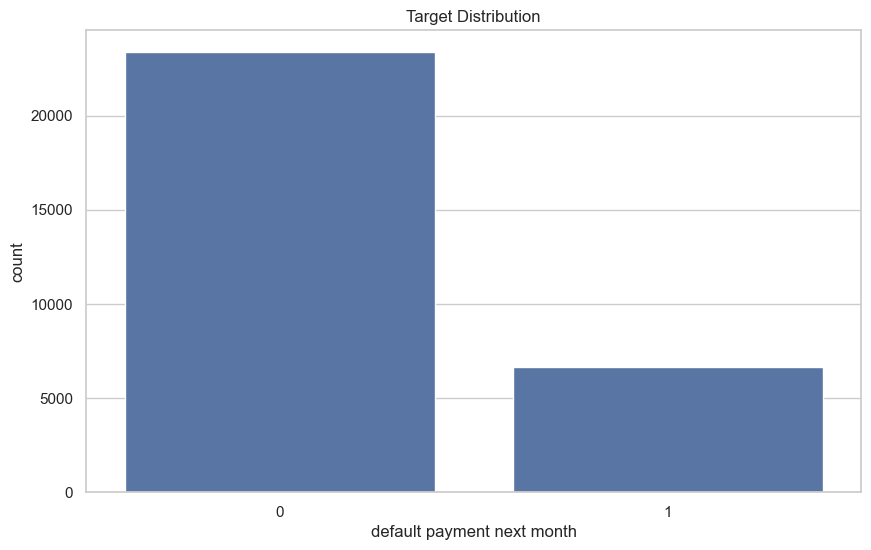

In [6]:
target_col = 'default payment next month'

print(org_df[target_col].value_counts())
print()
print(org_df[target_col].value_counts(normalize=True))

sns.countplot(data=org_df, x=target_col)
plt.title("Target Distribution")
plt.show()

* 이 데이터는 보통 부도 비율이 낮은 불균형 데이터이므로, 이후 평가 지표를 Accuracy만 쓰면 안 된다

## 1.5 결측치 확인

In [7]:
missing = org_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("결측치가 있는 컬럼 수:", missing.shape[0])
display(missing)

결측치가 있는 컬럼 수: 0


Series([], dtype: int64)

## 1.6 중복 확인

In [11]:
print("중복 행 수:", org_df.duplicated().sum())

중복 행 수: 0


## 1.7. 범주형 컬럼의 값 분포 확인

* SEX : 1=male, 2=female
* EDUCATION : 1=graduate school, 2=university, 3=high school, 4=others, 5=unknown, 6=unknown
* MARRIAGE : 1=married, 2=single, 3=others
* PAY_0, PAY_2, PAY_3, PAY_4, PAY_5, PAY_6

In [8]:
cat_cols = ['SEX', 'EDUCATION', 'MARRIAGE',
                 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

for col in cat_cols:
    print(f"\n[{col}] value counts")
    display(org_df[col].value_counts(dropna=False).sort_index())


[SEX] value counts


SEX
1    11888
2    18112
Name: count, dtype: int64


[EDUCATION] value counts


EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64


[MARRIAGE] value counts


...

PAY_4
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      180
 4       69
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64


[PAY_5] value counts


PAY_5
-2     4546
-1     5539
 0    16947
 2     2626
 3      178
 4       84
 5       17
 6        4
 7       58
 8        1
Name: count, dtype: int64


[PAY_6] value counts


PAY_6
-2     4895
-1     5740
 0    16286
 2     2766
 3      184
 4       49
 5       13
 6       19
 7       46
 8        2
Name: count, dtype: int64

## 1.7.2 범주형 컬럼의 값 - 수정

In [9]:
# EDUCATION : unknown, others, undefined => ohters
card_df['EDUCATION'] = card_df['EDUCATION'].replace([0,5,6],4)

# MARRIAGE
card_df['MARRIAGE'] = card_df['MARRIAGE'].replace([0,],3)

pay_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']

for col in pay_cols:
    print(col, sorted(card_df[col].unique()))

PAY_0 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_2 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_3 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_4 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_5 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_6 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


# 1.8 범주형 변수 시각화

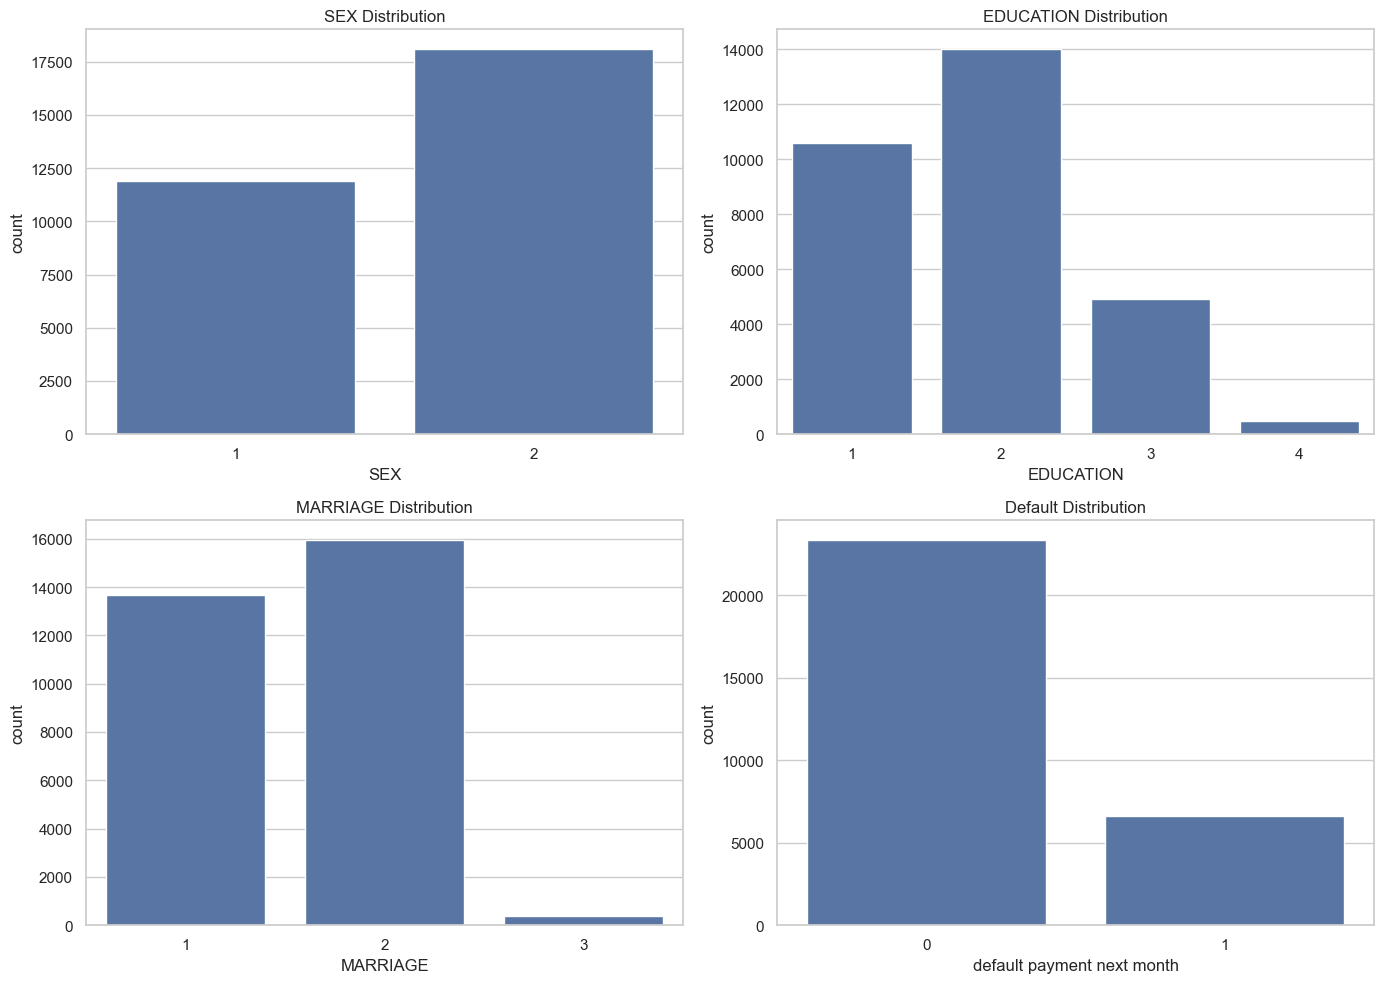

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=card_df, x='SEX', ax=axes[0, 0])
axes[0, 0].set_title('SEX Distribution')

sns.countplot(data=card_df, x='EDUCATION', ax=axes[0, 1])
axes[0, 1].set_title('EDUCATION Distribution')

sns.countplot(data=card_df, x='MARRIAGE', ax=axes[1, 0])
axes[1, 0].set_title('MARRIAGE Distribution')

sns.countplot(data=card_df, x=target_col, ax=axes[1, 1])
axes[1, 1].set_title('Default Distribution')

plt.tight_layout()
plt.show()

## 1.9 수치형 컬럼 확인

In [11]:
numeric_cols = card_df.select_dtypes(include=np.number).columns.tolist()

# 타깃과 ID는 제외해서 보는 경우가 많음 + 카테고리 제외
exclude_cols = ['ID', target_col] + cat_cols
num_cols = [col for col in numeric_cols if col not in exclude_cols]

print("수치형 변수 개수:", len(num_cols))
print(num_cols)

수치형 변수 개수: 14
['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


## 1.10 주요 수치형 변수 분포 확인

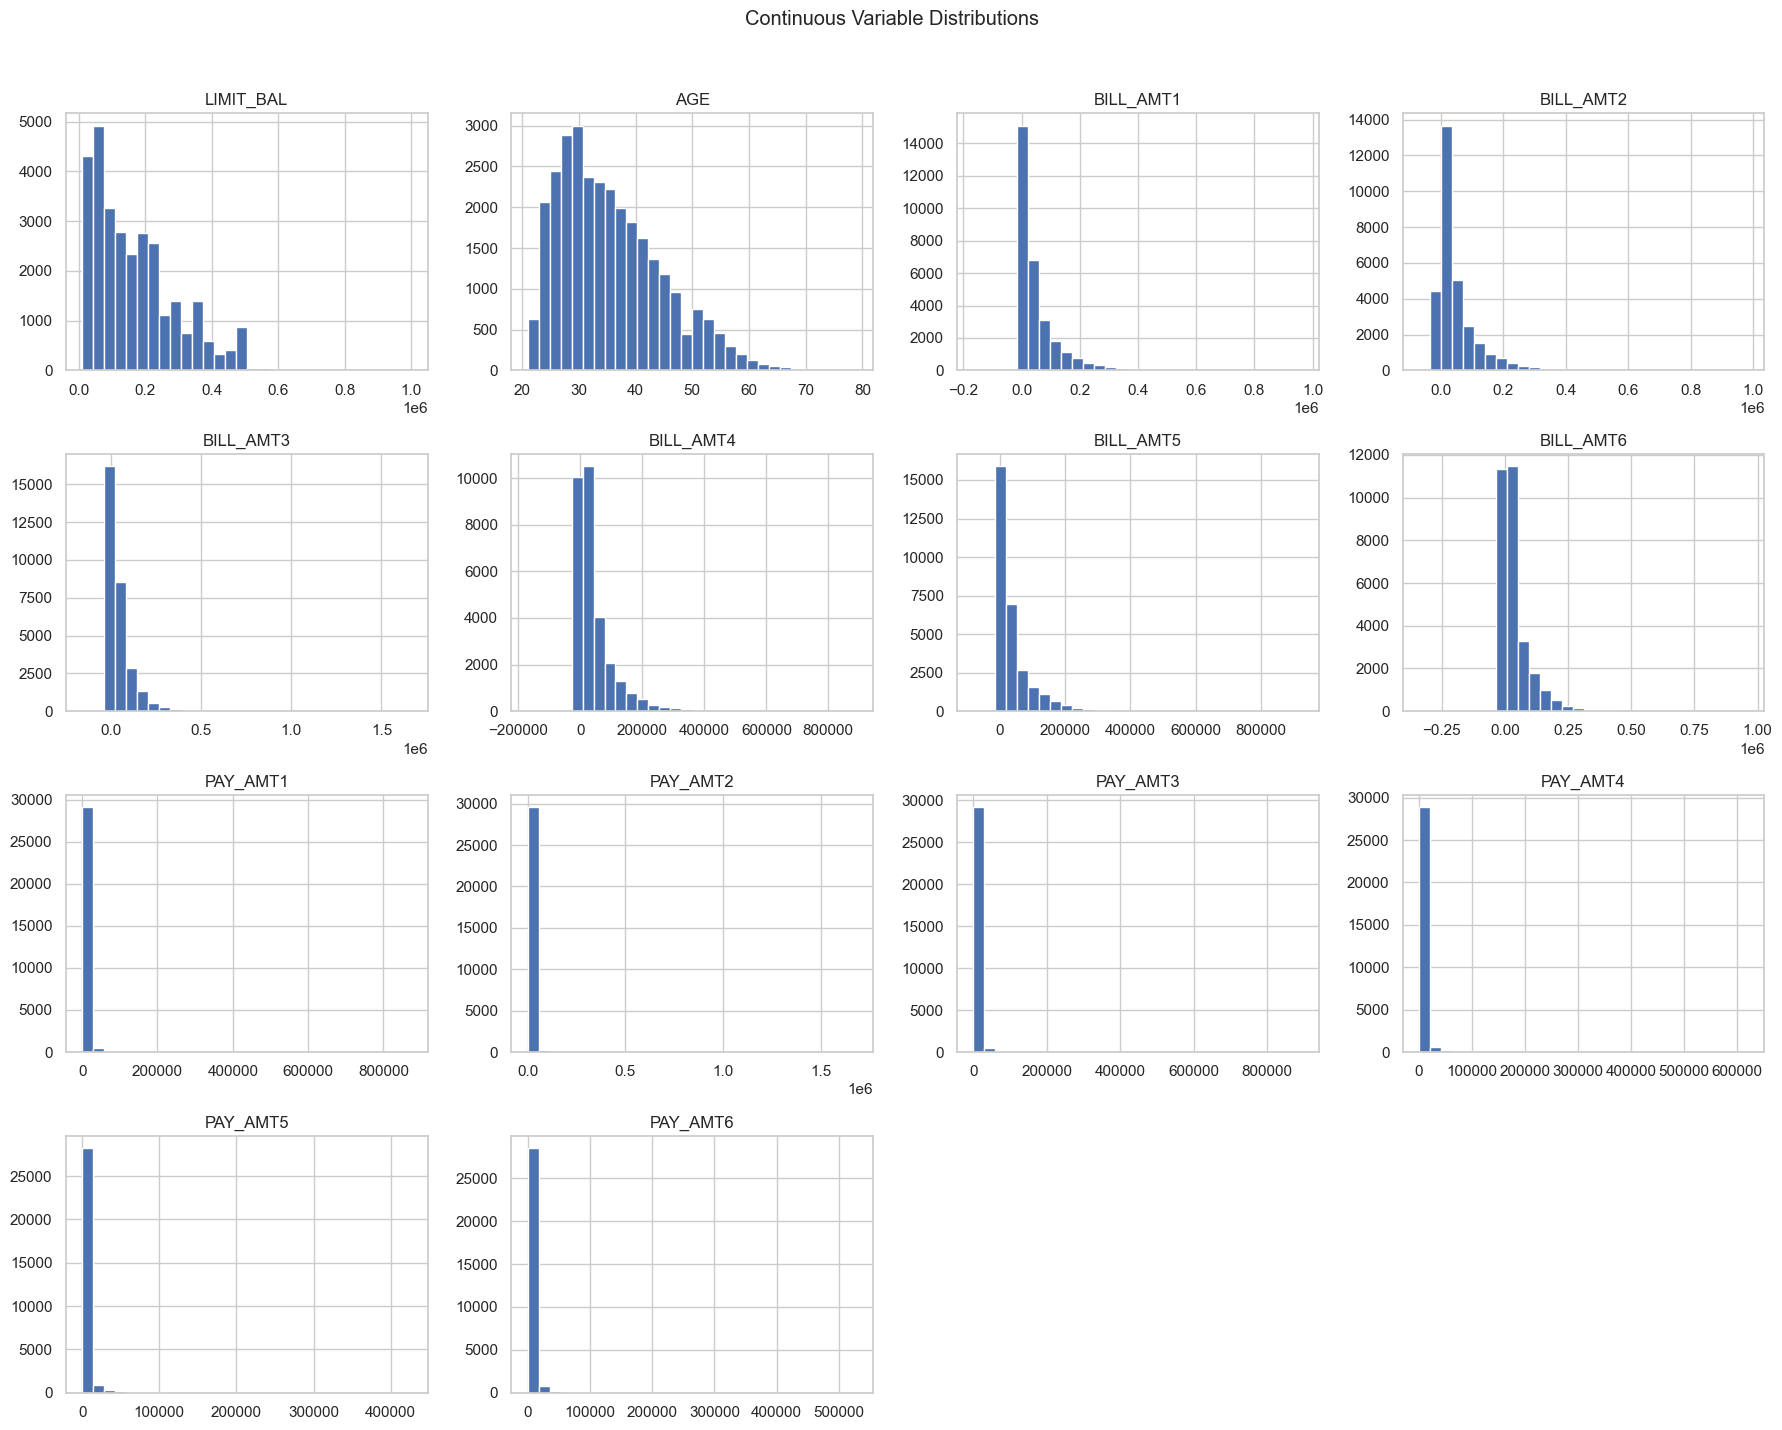

In [12]:
card_df[num_cols].hist(bins=30, figsize=(18, 14))
plt.suptitle("Continuous Variable Distributions", y=1.02)
plt.tight_layout()
plt.show()

# 1.11 Boxplot으로 이상치 후보 보기

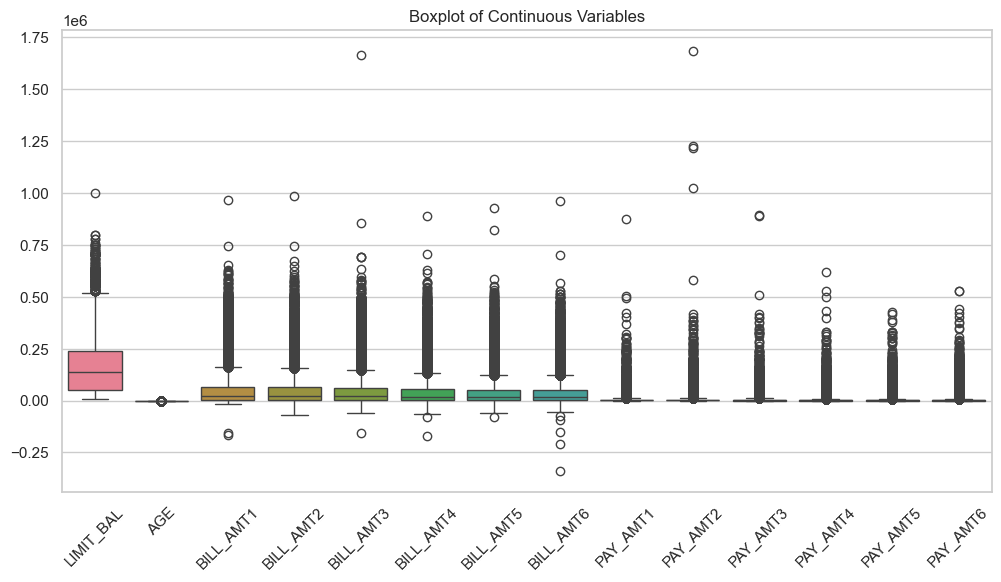

In [13]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=card_df[num_cols])
plt.xticks(rotation=45)
plt.title("Boxplot of Continuous Variables")
plt.show()

## 1.12 변수간 상관관계 분석

In [14]:
# 모든 변수와 target 간 상관관계 계산
corr_with_target = card_df.corr()[target_col].drop([target_col, 'ID'], axis=0)
# corr_with_target = card_df.corr()[target_col].drop(target_col)

# 절대값 기준 정렬
corr_with_target_sorted = corr_with_target.reindex(corr_with_target.abs().sort_values(ascending=False).index)

print("Feature vs Target Correlation")
display(corr_with_target_sorted)

Feature vs Target Correlation


PAY_0        0.324794
PAY_2        0.263551
PAY_3        0.235253
PAY_4        0.216614
PAY_5        0.204149
PAY_6        0.186866
LIMIT_BAL   -0.153520
PAY_AMT1    -0.072929
PAY_AMT2    -0.058579
PAY_AMT4    -0.056827
PAY_AMT3    -0.056250
PAY_AMT5    -0.055124
PAY_AMT6    -0.053183
SEX         -0.039961
EDUCATION    0.033842
MARRIAGE    -0.027575
BILL_AMT1   -0.019644
BILL_AMT2   -0.014193
BILL_AMT3   -0.014076
AGE          0.013890
BILL_AMT4   -0.010156
BILL_AMT5   -0.006760
BILL_AMT6   -0.005372
Name: default payment next month, dtype: float64

* 변수간 상관관계 분석 - 시각화

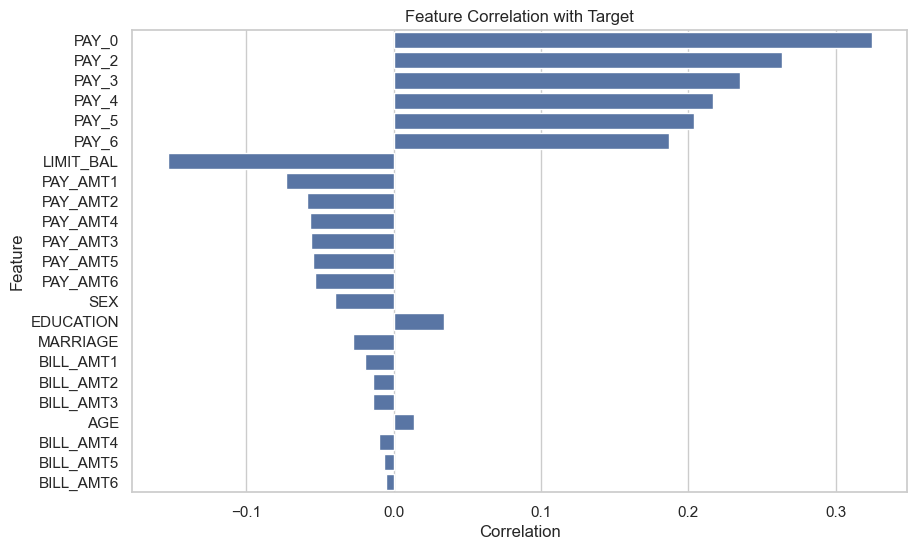

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    x=corr_with_target_sorted.values,
    y=corr_with_target_sorted.index
)

plt.title("Feature Correlation with Target")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.show()

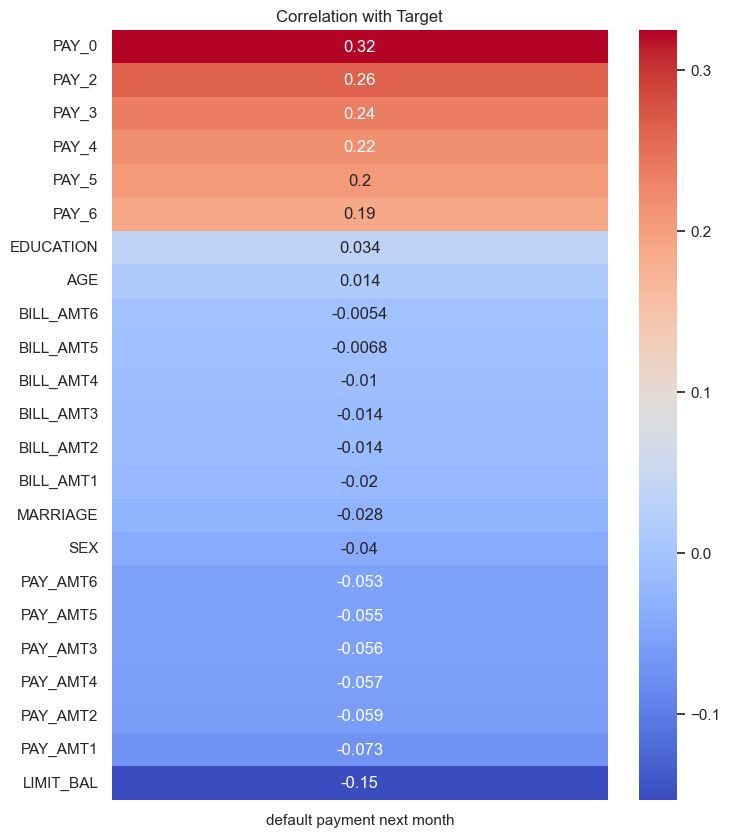

In [20]:
plt.figure(figsize=(8,10))

sns.heatmap(
    card_df.corr()[[target_col]].drop([target_col, 'ID']).sort_values(by=target_col, ascending=False),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation with Target")
plt.show()

# 2. 데이터 가공 (Preprocessing)

## 2.1 X, y 추출

In [16]:
card_df = card_df.rename(columns={'default payment next month': 'default'})

y_target = card_df['default']
X_features = card_df.drop(columns = ['ID','default'])

X_features, y_target

(       LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
 0          20000    2          2         1   24      2      2     -1     -1   
 1         120000    2          2         2   26     -1      2      0      0   
 2          90000    2          2         2   34      0      0      0      0   
 3          50000    2          2         1   37      0      0      0      0   
 4          50000    1          2         1   57     -1      0     -1      0   
 ...          ...  ...        ...       ...  ...    ...    ...    ...    ...   
 29995     220000    1          3         1   39      0      0      0      0   
 29996     150000    1          3         2   43     -1     -1     -1     -1   
 29997      30000    1          2         2   37      4      3      2     -1   
 29998      80000    1          3         1   41      1     -1      0      0   
 29999      50000    1          2         1   46      0      0      0      0   
 
        PAY_5  ...  BILL_AMT3  BILL_AM

## 2.2 데이터 분할 : 훈련용 vs 검증용

In [17]:
# Data 분리 및 Scaling
from sklearn.model_selection import train_test_split

# 훈련-검증 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X_features, y_target, test_size=0.2, random_state=42)


print("X_train shape:", X_train.shape)
print("X_valid shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_valid shape:", y_test.shape)

print("\n[train columns]")
print(X_train.columns.tolist())

X_train shape: (24000, 23)
X_valid shape: (6000, 23)
y_train shape: (24000,)
y_valid shape: (6000,)

[train columns]
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


# 3. 모델별 학습 및 예측

- LogisticRegression : 해석이 쉬움, 설명력 우선 - 비교용
- RandomForestClassifier : 튜닝이 상대적으로 쉬움 - 비교 기준으로 적합 
- LGBMClassifier : 성능 우선
- XGBClassifier : 성능 우선

# 3.1 LogisticRegression
- 범주형 변수 인코딩
- 수치형 변수 스케일링
- 모델 학습
- 예측 및 평가  

**Pipeline + ColumnTransformer**

* Column 분류

In [57]:
# categorical / numeric column 분리
cat_cols = ['SEX', 'EDUCATION', 'MARRIAGE',
            'PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']

num_cols = [col for col in X_train.columns if col not in cat_cols]

In [58]:
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix

# preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

# pipeline
lr_model = Pipeline(steps=[   # 수정: model -> lr_model
    ('preprocess', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced'
    ))
])

# training
lr_model.fit(X_train, y_train)   # 수정: model -> lr_model

# prediction
lr_y_pred = lr_model.predict(X_test)           # 수정: 변수명 변경
lr_y_prob = lr_model.predict_proba(X_test)[:,1] # 수정: 변수명 변경

# evaluation
print("Accuracy:", accuracy_score(y_test, lr_y_pred))   # 수정
print("ROC-AUC:", roc_auc_score(y_test, lr_y_prob))     # 수정

print("\nClassification Report")
print(classification_report(y_test, lr_y_pred))         # 수정

print("\nConfusion Matrix")
print(confusion_matrix(y_test, lr_y_pred))              # 수정

Accuracy: 0.7568333333333334
ROC-AUC: 0.774879912044642

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.79      0.84      4687
           1       0.46      0.62      0.53      1313

    accuracy                           0.76      6000
   macro avg       0.67      0.71      0.68      6000
weighted avg       0.79      0.76      0.77      6000


Confusion Matrix
[[3725  962]
 [ 497  816]]


### 결과 해석

1. Classification Report에서 먼저 확인해야 하는 것은 데이터 불균형입니다

| 클래스 | 의미    | 개수   |
| --- | ----- | ---- |
| 0   | 정상 고객 | 4687 |
| 1   | 부도 고객 | 1313 |

이 데이터는 불균형 데이터입니다. 그래서 Accuracy만으로 모델을 평가하면 안 됩니다.

정상에 비해 부도(class=1)에 대한 예측 성능이 낮아 별도의 조치가 필요함
- 데이터 증식: 부족한 1의 데이터를 늘리는 SMOTE 기법 활용
- 가중치 조정: 모델 학습 시 1에 대해 더 큰 벌점을 주는 Class Weight 설정
- 임계값 조정: Recall을 높이기 위해 분류 임계값(Threshold) 하향 조정


### [개념 정리] ROC-AUC 지표

ROC-AUC는 이진 분류(Binary Classification) 모델의 성능을 측정하는 지표로, 모델이 클래스를 얼마나 잘 구별하는지 수치화한 것입니다.
1. ROC (Receiver Operating Characteristic) 곡선
다양한 임계값(Threshold) 변화에 따른 모델의 분류 성능을 시각적으로 나타낸 그래프입니다.

* X축: FPR (False Positive Rate)
* 실제 음성(Negative) 중 양성(Positive)으로 잘못 예측한 비율입니다. ($1 - \text{특이도}$)
* Y축: TPR (True Positive Rate)
* 실제 양성(Positive) 중 양성으로 올바르게 예측한 비율입니다. (재현율 또는 민감도)
* 해석: 곡선이 왼쪽 상단 구석($0, 1$)에 가깝게 붙을수록 성능이 우수한 모델입니다.

2. AUC (Area Under the Curve)
ROC 곡선 아래의 면적을 의미하며, 모델의 성능을 하나의 숫자로 요약해 줍니다.

| AUC 수치 | 의미 |
|---|---|
| 1.0 | 완벽하게 분류하는 최상의 모델 |
| 0.8 ~ 0.9 | 매우 훌륭한 분류 성능 |
| 0.7 ~ 0.8 | 준수한 분류 성능 |
| 0.5 | 무작위 추측(Random Guess) 수준 |

3. ROC-AUC의 주요 장점

   1. 임계값 독립성: 특정 임계값(0.5 등)에 국한되지 않고, 모델의 전반적인 식별 능력을 평가합니다.
   2. 데이터 불균형에 강함: 정확도(Accuracy)는 클래스 비율이 불균형할 때 왜곡될 수 있지만, ROC-AUC는 양성과 음성 각각의 비율을 고려하므로 더 객관적인 평가가 가능합니다.

# 3.2 RandomForestClassifier

In [59]:
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

# pipeline
rf_model = Pipeline(steps=[   # 수정: model -> rf_model (모델 구분을 위해 변경)
    ('preprocess', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    ))
])

# training
rf_model.fit(X_train, y_train)   # 수정: model -> rf_model

# prediction
rf_y_pred = rf_model.predict(X_test)   # 수정: 결과 변수명 변경
rf_y_prob = rf_model.predict_proba(X_test)[:, 1]   # 수정: 결과 변수명 변경

# evaluation
print("Accuracy:", accuracy_score(y_test, rf_y_pred))   # 수정: rf_y_pred 사용
print("ROC-AUC:", roc_auc_score(y_test, rf_y_prob))     # 수정: rf_y_prob 사용

print("\nClassification Report")
print(classification_report(y_test, rf_y_pred))         # 수정

print("\nConfusion Matrix")
print(confusion_matrix(y_test, rf_y_pred))              # 수정

Accuracy: 0.8158333333333333
ROC-AUC: 0.760914431532763

Classification Report
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4687
           1       0.65      0.34      0.45      1313

    accuracy                           0.82      6000
   macro avg       0.74      0.65      0.67      6000
weighted avg       0.80      0.82      0.79      6000


Confusion Matrix
[[4445  242]
 [ 863  450]]


### ROC Curve 비교 그래프 코드

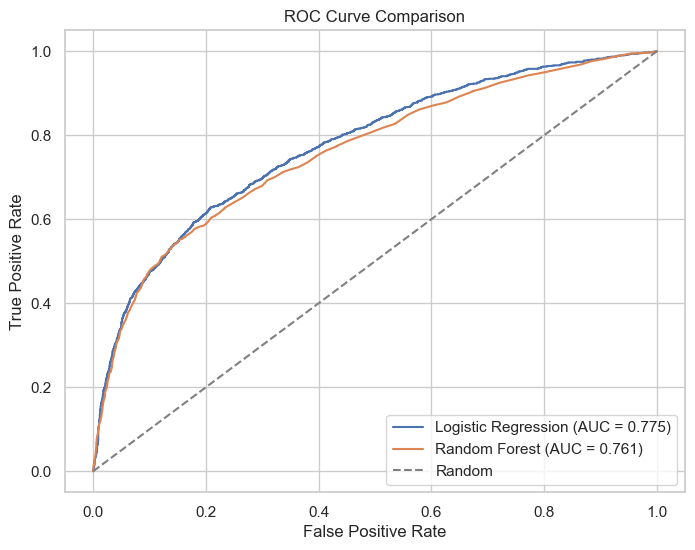

In [61]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# ROC Curve 계산
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_y_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_y_prob)

# AUC 계산
lr_auc = roc_auc_score(y_test, lr_y_prob)
rf_auc = roc_auc_score(y_test, rf_y_prob)

# 그래프 생성
plt.figure(figsize=(8,6))

# Logistic Regression
plt.plot(
    lr_fpr, lr_tpr,
    label=f'Logistic Regression (AUC = {lr_auc:.3f})'
)

# Random Forest
plt.plot(
    rf_fpr, rf_tpr,
    label=f'Random Forest (AUC = {rf_auc:.3f})'
)

# 랜덤 모델 기준선
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Random')

# 그래프 설정
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')

plt.grid(True)
plt.show()

# 3.3 LGBMClassifier & XGBClassifier

* Decision Tree 기반 분류 모델 학습 및 테스트 공통 모듈

In [ ]:
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# 선택: 설치가 안 되어 있으면 먼저 설치 필요
# pip install lightgbm xgboost

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier


def train_evaluate_tree_model(
    model,
    X_train,
    y_train,
    X_test,
    y_test,
    cat_cols,
    num_cols,
    prefix="model"
):
    """
    트리 기반 분류 모델(LightGBM, XGBoost, RandomForest 등)에 대해
    공통 전처리 + 학습 + 예측 + 평가를 수행하는 함수
    """

    # 트리 모델은 스케일링이 필수는 아니므로 수치형은 그대로 사용
    # 범주형은 OneHotEncoder 처리
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', 'passthrough', num_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
        ]
    )

    pipeline = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('classifier', model)
    ])

    # 학습
    pipeline.fit(X_train, y_train)

    # 예측
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    # 평가
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    print(f"[{prefix}] Accuracy: {acc:.4f}")
    print(f"[{prefix}] ROC-AUC: {auc:.4f}")

    print(f"\n[{prefix}] Classification Report")
    print(classification_report(y_test, y_pred))

    print(f"\n[{prefix}] Confusion Matrix")
    print(confusion_matrix(y_test, y_pred))

    # 비교용 결과 반환 : Dictionary 형식
    return {
        f"{prefix}_model": pipeline,
        f"{prefix}_y_pred": y_pred,
        f"{prefix}_y_prob": y_prob,
        f"{prefix}_accuracy": acc,
        f"{prefix}_roc_auc": auc
    }

## LGBMClassifier 학습 및 테스트

In [22]:
lgb_result = train_evaluate_tree_model(
    model=LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    ),
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    cat_cols=cat_cols,
    num_cols=num_cols,
    prefix="lgb"
)

# 결과 변수 꺼내기
lgb_model = lgb_result["lgb_model"]
lgb_y_pred = lgb_result["lgb_y_pred"]
lgb_y_prob = lgb_result["lgb_y_prob"]

[LightGBM] [Info] Number of positive: 5323, number of negative: 18677
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000995 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3292
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 66
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[lgb] Accuracy: 0.7570
[lgb] ROC-AUC: 0.7814

[lgb] Classification Report
              precision    recall  f1-score   support

           0       0.88      0.80      0.84      4687
           1       0.46      0.62      0.53      1313

    accuracy                           0.76      6000
   macro avg       0.67      0.71      0.68      6000
weighted avg       0.79      0.76      0.77      6000


[lgb] Confusion Matrix
[[3730  957]
 [ 501  812]]


## XGBClassifier 학습 및 테스트

In [23]:
xgb_result = train_evaluate_tree_model(
    model=XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss'
    ),
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    cat_cols=cat_cols,
    num_cols=num_cols,
    prefix="xgb"
)

# 결과 변수 꺼내기
xgb_model = xgb_result["xgb_model"]
xgb_y_pred = xgb_result["xgb_y_pred"]
xgb_y_prob = xgb_result["xgb_y_prob"]

[xgb] Accuracy: 0.8255
[xgb] ROC-AUC: 0.7831

[xgb] Classification Report
              precision    recall  f1-score   support

           0       0.84      0.95      0.90      4687
           1       0.69      0.37      0.48      1313

    accuracy                           0.83      6000
   macro avg       0.77      0.66      0.69      6000
weighted avg       0.81      0.83      0.80      6000


[xgb] Confusion Matrix
[[4469  218]
 [ 829  484]]


# 4. 전체 모델 비교

In [62]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results = pd.DataFrame({
    'Model': ['LogisticRegression', 'RandomForest', 'LightGBM', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, lr_y_pred),
        accuracy_score(y_test, rf_y_pred),
        accuracy_score(y_test, lgb_y_pred),
        accuracy_score(y_test, xgb_y_pred)
    ],
    'Precision': [
        precision_score(y_test, lr_y_pred),
        precision_score(y_test, rf_y_pred),
        precision_score(y_test, lgb_y_pred),
        precision_score(y_test, xgb_y_pred)
    ],
    'Recall': [
        recall_score(y_test, lr_y_pred),
        recall_score(y_test, rf_y_pred),
        recall_score(y_test, lgb_y_pred),
        recall_score(y_test, xgb_y_pred)
    ],
    'F1-Score': [
        f1_score(y_test, lr_y_pred),
        f1_score(y_test, rf_y_pred),
        f1_score(y_test, lgb_y_pred),
        f1_score(y_test, xgb_y_pred)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, lr_y_prob),
        roc_auc_score(y_test, rf_y_prob),
        roc_auc_score(y_test, lgb_y_prob),
        roc_auc_score(y_test, xgb_y_prob)
    ]
})

results = results.sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)
results[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']] = (
    results[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].round(4)
)

display(results)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,XGBoost,0.7532,0.4542,0.6344,0.5294,0.7834
1,LightGBM,0.5437,0.3076,0.8675,0.4541,0.7779
2,LogisticRegression,0.7568,0.4589,0.6215,0.5280,0.7749
3,RandomForest,0.8158,0.6503,0.3427,0.4489,0.7609


# 5. 데이터 가공 2차 (2nd Preprocessing)

- 부도율(Target Value) 데이터 불균형 : scale_pos_weight 적용
- 수치형 입력 데이터 Long Tail 현상 : log transform 적용

In [ ]:
# # Long-tail 분포를 가진 변수 subset

# # long_tail_cols = num_cols - ['AGE'] - 오류 코드
# long_tail_cols = [col for col in num_cols if col != 'AGE']

# for col in long_tail_cols:
#     X_train[col + '_log'] = np.log1p(X_train[col])
#     X_test[col + '_log'] = np.log1p(X_test[col])
    
# X_train.head()

In [ ]:
# log_cols = [col for col in X_train.columns if col.endswith('_log')]

# X_train = X_train.drop(columns=log_cols, errors='ignore')
# X_test = X_test.drop(columns=log_cols, errors='ignore')

In [ ]:
# num_cols = [col for col in num_cols if not col.endswith('_log')]

## 5.1 Target 데이터 불균형 완화

* scale_pos_weight 산정 - 모델 파라미터로 사용 에정

In [43]:
# scale_pos_weight 계산
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 3.5087356753710313


## 5.2 수치형 입력 데이터 Log 변환 : Log 컬럼 추가

* LightGBM / XGBoost 같은 트리 기반 모델에서는 원본과 log 변환 데이터를 함께 사용

* Log 적용 시 NaN 이 생기지 않도록 마이너스 값이 있는 컬럼은 제외

In [40]:
import numpy as np

long_tail_cols = [col for col in num_cols if col != 'AGE']

log_safe_cols = []
for col in long_tail_cols:
    if X_train[col].min() > -1 and X_test[col].min() > -1:
        log_safe_cols.append(col)

for col in log_safe_cols:
    X_train[col + '_log'] = np.log1p(X_train[col])
    X_test[col + '_log'] = np.log1p(X_test[col])

print("log_safe_cols:", log_safe_cols)

log_safe_cols: ['LIMIT_BAL', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


In [ ]:
# num_cols 재정의 : 추가된 컬럼 반영 <= cat-cols 제외하고 다시 생성
num_cols = [col for col in X_train.columns if col not in cat_cols]

In [56]:
print(num_cols[:11])
print(num_cols[11:])

['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3']
['PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'LIMIT_BAL_log', 'PAY_AMT1_log', 'PAY_AMT2_log', 'PAY_AMT3_log', 'PAY_AMT4_log', 'PAY_AMT5_log', 'PAY_AMT6_log']


* NaN 필드 확인

In [53]:
log_cols = [col for col in X_train.columns if col.endswith('_log')]

print("train log NaN")
print(X_train[log_cols].isna().sum()[X_train[log_cols].isna().sum() > 0])

print("test log NaN")
print(X_test[log_cols].isna().sum()[X_test[log_cols].isna().sum() > 0])

train log NaN
Series([], dtype: int64)
test log NaN
Series([], dtype: int64)


# 6. 선정된 모델 재학습 - XGBClassifier, LGBMClassifier

# 6.1 XGBClassifier

In [ ]:
# 결과 변수 꺼내기
# xgb_model = xgb_result["xgb_model"]

# 기존 모델의 파라미터 수정
# xgb_model.set_params(classifier__scale_pos_weight=scale_pos_weight)

# 기존 pipeline 내부의 classifier(XGBClassifier)만 꺼내기
xgb_core = xgb_model.named_steps['classifier']

# classifier 파라미터 수정
xgb_core.set_params(scale_pos_weight=scale_pos_weight)

# 다시 학습
xgb_result = train_evaluate_tree_model(
    model=xgb_core, # xgb_core 적용
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    cat_cols=cat_cols,
    num_cols=num_cols,
    prefix="xgb"
)

# 결과 변수 꺼내기
xgb_model = xgb_result["xgb_model"]
xgb_y_pred = xgb_result["xgb_y_pred"]
xgb_y_prob = xgb_result["xgb_y_prob"]

[xgb] Accuracy: 0.7532
[xgb] ROC-AUC: 0.7834

[xgb] Classification Report
              precision    recall  f1-score   support

           0       0.88      0.79      0.83      4687
           1       0.45      0.63      0.53      1313

    accuracy                           0.75      6000
   macro avg       0.67      0.71      0.68      6000
weighted avg       0.79      0.75      0.77      6000


[xgb] Confusion Matrix
[[3686 1001]
 [ 480  833]]


# 6.2 LGBMClassifier

In [46]:
lgb_core = lgb_model.named_steps['classifier']

lgb_core.set_params(scale_pos_weight=scale_pos_weight)

lgb_result = train_evaluate_tree_model(
    model=lgb_core,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    cat_cols=cat_cols,
    num_cols=num_cols,
    prefix="lgb"
)

lgb_model = lgb_result["lgb_model"]
lgb_y_pred = lgb_result["lgb_y_pred"]
lgb_y_prob = lgb_result["lgb_y_prob"]

[LightGBM] [Info] Number of positive: 5323, number of negative: 18677
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001435 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4895
[LightGBM] [Info] Number of data points in the train set: 24000, number of used features: 73
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[lgb] Accuracy: 0.5437
[lgb] ROC-AUC: 0.7779

[lgb] Classification Report
              precision    recall  f1-score   support

           0       0.92      0.45      0.61      4687
           1       0.31      0.87      0.45      1313

    accuracy                           0.54      6000
   macro avg       0.62      0.66      0.53      6000
weighted avg       0.79      0.54      0.57      6000


[lgb] Confusion Matrix
[[2123 2564]
 [ 174 1139]]


In [63]:
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

compare_results = pd.DataFrame({
    'Model': ['XGBoost', 'LightGBM'],
    'Accuracy': [
        accuracy_score(y_test, xgb_y_pred),
        accuracy_score(y_test, lgb_y_pred)
    ],
    'Precision': [
        precision_score(y_test, xgb_y_pred),
        precision_score(y_test, lgb_y_pred)
    ],
    'Recall': [
        recall_score(y_test, xgb_y_pred),
        recall_score(y_test, lgb_y_pred)
    ],
    'F1-Score': [
        f1_score(y_test, xgb_y_pred),
        f1_score(y_test, lgb_y_pred)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, xgb_y_prob),
        roc_auc_score(y_test, lgb_y_prob)
    ]
})

compare_results = compare_results.sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)

metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
compare_results[metric_cols] = compare_results[metric_cols].round(4)

display(compare_results)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,XGBoost,0.7532,0.4542,0.6344,0.5294,0.7834
1,LightGBM,0.5437,0.3076,0.8675,0.4541,0.7779


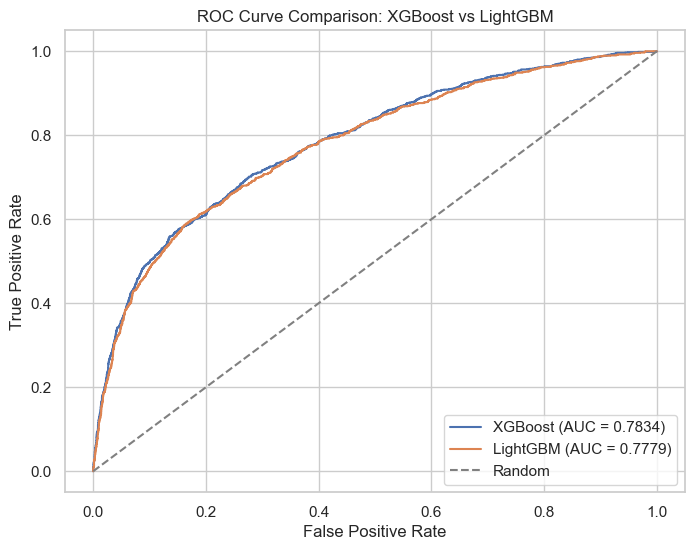

In [64]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# ROC curve 계산
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_y_prob)
lgb_fpr, lgb_tpr, _ = roc_curve(y_test, lgb_y_prob)

# AUC 계산
xgb_auc = roc_auc_score(y_test, xgb_y_prob)
lgb_auc = roc_auc_score(y_test, lgb_y_prob)

# 그래프
plt.figure(figsize=(8, 6))

plt.plot(xgb_fpr, xgb_tpr, label=f'XGBoost (AUC = {xgb_auc:.4f})')
plt.plot(lgb_fpr, lgb_tpr, label=f'LightGBM (AUC = {lgb_auc:.4f})')

# 랜덤 기준선
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: XGBoost vs LightGBM')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

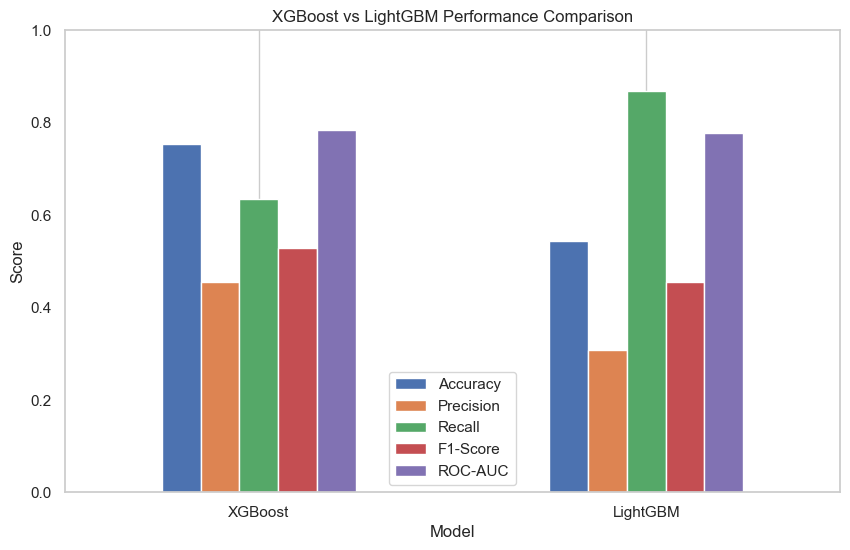

In [51]:
plot_df = compare_results.set_index('Model')

plot_df.plot(kind='bar', figsize=(10, 6))
plt.title('XGBoost vs LightGBM Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.grid(axis='y')
plt.show()

,Model,Accuracy_Before,Accuracy_After,Accuracy_Change,Precision_Before,Precision_After,Precision_Change,Recall_Before,Recall_After,Recall_Change,F1-Score_Before,F1-Score_After,F1-Score_Change,ROC-AUC_Before,ROC-AUC_After,ROC-AUC_Change
0,XGBoost,0.8255,0.7532,-0.0723,0.6895,0.4542,-0.2353,0.3686,0.6344,0.2658,0.4804,0.5294,0.0490,0.7831,0.7834,0.0003
1,LightGBM,0.7570,0.5437,-0.2133,0.4590,0.3076,-0.1514,0.6184,0.8675,0.2491,0.5269,0.4541,-0.0728,0.7814,0.7779,-0.0035


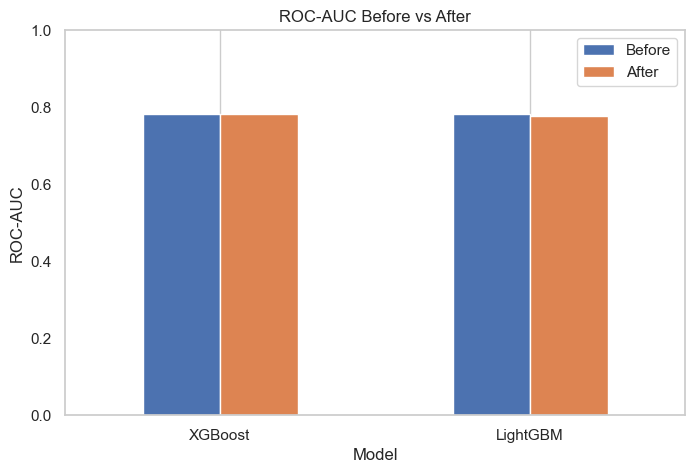

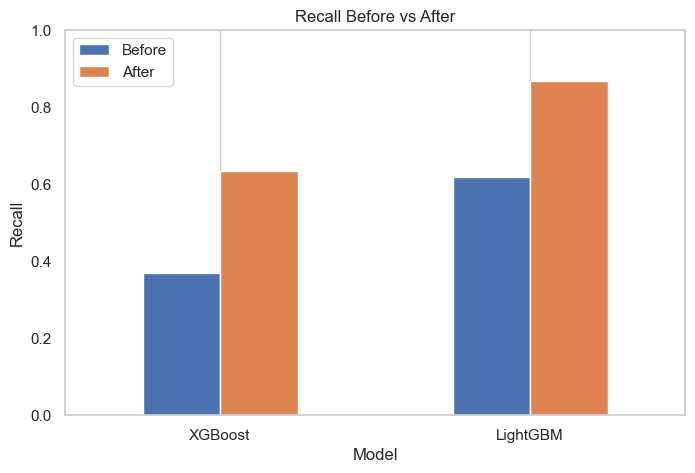

In [65]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# 1차 결과
before_results = pd.DataFrame({
    'Model': ['XGBoost', 'LightGBM'],
    'Accuracy': [0.8255, 0.7570],
    'Precision': [0.6895, 0.4590],
    'Recall': [0.3686, 0.6184],
    'F1-Score': [0.4804, 0.5269],
    'ROC-AUC': [0.7831, 0.7814]
})

# 2차 결과
after_results = pd.DataFrame({
    'Model': ['XGBoost', 'LightGBM'],
    'Accuracy': [
        accuracy_score(y_test, xgb_y_pred),
        accuracy_score(y_test, lgb_y_pred)
    ],
    'Precision': [
        precision_score(y_test, xgb_y_pred),
        precision_score(y_test, lgb_y_pred)
    ],
    'Recall': [
        recall_score(y_test, xgb_y_pred),
        recall_score(y_test, lgb_y_pred)
    ],
    'F1-Score': [
        f1_score(y_test, xgb_y_pred),
        f1_score(y_test, lgb_y_pred)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, xgb_y_prob),
        roc_auc_score(y_test, lgb_y_prob)
    ]
}).round(4)

# 비교 테이블 생성
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

compare_before_after = before_results.merge(
    after_results,
    on='Model',
    suffixes=('_Before', '_After')
)

for metric in metric_cols:
    compare_before_after[f'{metric}_Change'] = (
        compare_before_after[f'{metric}_After'] - compare_before_after[f'{metric}_Before']
    ).round(4)

ordered_cols = ['Model']
for metric in metric_cols:
    ordered_cols.extend([
        f'{metric}_Before',
        f'{metric}_After',
        f'{metric}_Change'
    ])

compare_before_after = compare_before_after[ordered_cols]

display(compare_before_after)

# ROC-AUC 그래프
plot_auc = pd.DataFrame({
    'Model': ['XGBoost', 'LightGBM'],
    'Before': before_results['ROC-AUC'],
    'After': after_results['ROC-AUC']
}).set_index('Model')

plot_auc.plot(kind='bar', figsize=(8, 5))
plt.title('ROC-AUC Before vs After')
plt.ylabel('ROC-AUC')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.grid(axis='y')
plt.show()

# Recall 그래프
plot_recall = pd.DataFrame({
    'Model': ['XGBoost', 'LightGBM'],
    'Before': before_results['Recall'],
    'After': after_results['Recall']
}).set_index('Model')

plot_recall.plot(kind='bar', figsize=(8, 5))
plt.title('Recall Before vs After')
plt.ylabel('Recall')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.grid(axis='y')
plt.show()

# 7. Tuning and Feature Engineering

## 7.1 Threshold Tuning

In [68]:
xgb_model.predict_proba(X_test)

array([[0.52812356, 0.47187644],
       [0.7802119 , 0.21978809],
       [0.64205825, 0.35794172],
       ...,
       [0.58832806, 0.41167194],
       [0.5270108 , 0.4729892 ],
       [0.8874632 , 0.11253677]], shape=(6000, 2), dtype=float32)

* 부도(target=1)일 확률

In [78]:
xgb_y_prob = xgb_model.predict_proba(X_test)[:,1]
xgb_y_prob

array([0.47187644, 0.21978809, 0.35794172, ..., 0.41167194, 0.4729892 ,
       0.11253677], shape=(6000,), dtype=float32)

* 부도 확률의 Threshold 를 조정하여 부도여부를 재판단

In [79]:
import pandas as pd
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.3, 0.35, 0.4, 0.45, 0.5]

results = []

for t in thresholds:
    
    pred = (xgb_y_prob >= t).astype(int)
    
    results.append({
        "threshold": t,
        "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred)
    })

threshold_df = pd.DataFrame(results)

display(threshold_df)

,threshold,precision,recall,f1
0,0.30,0.307589,0.870526,0.454564
1,0.35,0.340419,0.805027,0.478497
2,0.40,0.382574,0.735720,0.503387
3,0.45,0.422622,0.680122,0.521308
4,0.50,0.454198,0.634425,0.529393


### threshold 설정 기준

* Recall ≥ 0.7 유지  =>  threshold <= 0.4
* Precision 최대   
- **threshold = 0.4**

## 7.2 Feature Engineering

- credit_utilization = 최근 청구금액 / 한도

- payment_ratio = 최근 결제금액 / 최근 청구금액

- late_payment_count = 연체 발생 횟수

In [92]:
import numpy as np

# -----------------------------------
# 1. Feature Engineering
# -----------------------------------

# 원본 보존을 위해 copy 사용
X_train_fe = X_train.copy()
X_test_fe = X_test.copy()

# 1) credit_utilization
X_train_fe['credit_utilization'] = X_train_fe['BILL_AMT1'] / (X_train_fe['LIMIT_BAL'] + 1e-6)
X_test_fe['credit_utilization'] = X_test_fe['BILL_AMT1'] / (X_test_fe['LIMIT_BAL'] + 1e-6)

# 2) payment_ratio
X_train_fe['payment_ratio'] = X_train_fe['PAY_AMT1'] / (np.abs(X_train_fe['BILL_AMT1']) + 1e-6)
X_test_fe['payment_ratio'] = X_test_fe['PAY_AMT1'] / (np.abs(X_test_fe['BILL_AMT1']) + 1e-6)

# 3) late_payment_count
pay_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']

X_train_fe['late_payment_count'] = (X_train_fe[pay_cols] > 0).sum(axis=1)
X_test_fe['late_payment_count'] = (X_test_fe[pay_cols] > 0).sum(axis=1)

# -----------------------------------
# 2. num_cols 재정의
# -----------------------------------

num_cols_fe = [col for col in X_train_fe.columns if col not in cat_cols]

# -----------------------------------
# 3. 기존 XGB 모델 core 추출
# -----------------------------------

xgb_core = xgb_model.named_steps['classifier']

# imbalance parameter 유지
xgb_core.set_params(scale_pos_weight=scale_pos_weight)

# -----------------------------------
# 4. 모델 재학습
# -----------------------------------

xgb_result_fe = train_evaluate_tree_model(
    model=xgb_core,
    X_train=X_train_fe,
    y_train=y_train,
    X_test=X_test_fe,
    y_test=y_test,
    cat_cols=cat_cols,
    num_cols=num_cols_fe,
    prefix="xgb_fe"
)

# 결과 변수
xgb_model_fe = xgb_result_fe["xgb_fe_model"]
xgb_y_prob_fe = xgb_result_fe["xgb_fe_y_prob"]

# -----------------------------------
# 5. threshold = 0.4 적용
# -----------------------------------

threshold = 0.4

xgb_y_pred_fe = (xgb_y_prob_fe >= threshold).astype(int)

[xgb_fe] Accuracy: 0.7500
[xgb_fe] ROC-AUC: 0.7843

[xgb_fe] Classification Report
              precision    recall  f1-score   support

           0       0.88      0.78      0.83      4687
           1       0.45      0.63      0.53      1313

    accuracy                           0.75      6000
   macro avg       0.67      0.71      0.68      6000
weighted avg       0.79      0.75      0.76      6000


[xgb_fe] Confusion Matrix
[[3668 1019]
 [ 481  832]]


## 성능 평가

In [93]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("Threshold:", threshold)

print("Accuracy:", accuracy_score(y_test, xgb_y_pred_fe))
print("Precision:", precision_score(y_test, xgb_y_pred_fe))
print("Recall:", recall_score(y_test, xgb_y_pred_fe))
print("F1 Score:", f1_score(y_test, xgb_y_pred_fe))

print("\nROC-AUC:", roc_auc_score(y_test, xgb_y_prob_fe))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, xgb_y_pred_fe))

Threshold: 0.4
Accuracy: 0.6676666666666666
Precision: 0.37155790267823463
Recall: 0.7501904036557502
F1 Score: 0.49697275479313824

ROC-AUC: 0.7843488276220902

Confusion Matrix
[[3021 1666]
 [ 328  985]]


In [90]:
threshold = 0.42

xgb_y_pred_fe = (xgb_y_prob_fe >= threshold).astype(int)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("Threshold:", threshold)

print("Accuracy:", accuracy_score(y_test, xgb_y_pred_fe))
print("Precision:", precision_score(y_test, xgb_y_pred_fe))
print("Recall:", recall_score(y_test, xgb_y_pred_fe))
print("F1 Score:", f1_score(y_test, xgb_y_pred_fe))

print("\nROC-AUC:", roc_auc_score(y_test, xgb_y_prob_fe))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, xgb_y_pred_fe))

=> Feature Engineering 전
- **0.40** :	0.382574,	0.735720,	0.503387  

=> Feature Engineering 후
- **0.40** :   0.371557,    0.750190,    0.496972
- **0.42** :   0.391215,   0.732673,    0.510074

=> threshold 0.42 로 최적화

## 원래 속성명 기준 Feature Importance 집계 코드

1. 전처리 후 feature 이름 추출

2. XGBoost importance 추출

3. One-hot 분리된 항목을 원래 속성명 기준으로 집계

4. 중요도 순으로 출력

In [94]:
import pandas as pd
import re

# 현재 사용 중인 모델 객체
# 예: feature engineering 적용 후 모델이면 xgb_model_fe
model_pipeline = xgb_model_fe

# 1) 전처리기 / 분류기 추출
preprocessor = model_pipeline.named_steps['preprocess']
classifier = model_pipeline.named_steps['classifier']

# 2) 전처리 후 실제 feature 이름 추출
feature_names = preprocessor.get_feature_names_out()

# 3) XGBoost feature importance 추출
importances = classifier.feature_importances_

# 4) 전처리 feature 기준 importance DataFrame
fi_detail = pd.DataFrame({
    'feature_transformed': feature_names,
    'importance': importances
})

# 5) 전처리된 feature 이름을 원래 속성명으로 되돌리는 함수
def to_original_feature_name(transformed_name: str) -> str:
    # num__BILL_AMT1 → BILL_AMT1
    if transformed_name.startswith('num__'):
        return transformed_name.replace('num__', '')
    
    # cat__SEX_1 → SEX
    # cat__PAY_0_-1 → PAY_0
    if transformed_name.startswith('cat__'):
        col = transformed_name.replace('cat__', '')
        
        # cat_cols 안에서 가장 먼저 매칭되는 원래 컬럼명 찾기
        for c in sorted(cat_cols, key=len, reverse=True):
            if col == c or col.startswith(c + '_'):
                return c
        
        # 혹시 매칭 실패하면 첫 번째 토큰 사용
        return col.split('_')[0]
    
    return transformed_name

# 6) 원래 속성명 컬럼 추가
fi_detail['feature_original'] = fi_detail['feature_transformed'].apply(to_original_feature_name)

# 7) 원래 속성명 기준으로 importance 합산
fi_grouped = (
    fi_detail
    .groupby('feature_original', as_index=False)['importance']
    .sum()
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

# 8) 비중(%) 계산
fi_grouped['importance_pct'] = fi_grouped['importance'] / fi_grouped['importance'].sum() * 100

# 9) 보기 좋게 반올림
fi_grouped['importance'] = fi_grouped['importance'].round(6)
fi_grouped['importance_pct'] = fi_grouped['importance_pct'].round(2)

display(fi_grouped)

,feature_original,importance,importance_pct
0,late_payment_count,0.252707,25.27
1,PAY_0,0.156549,15.65
2,PAY_3,0.130381,13.04
3,PAY_2,0.096289,9.63
4,PAY_5,0.035271,3.53
5,PAY_4,0.031610,3.16
6,PAY_6,0.027249,2.72
7,EDUCATION,0.026734,2.67
8,PAY_AMT1_log,0.026087,2.61
9,MARRIAGE,0.020830,2.08


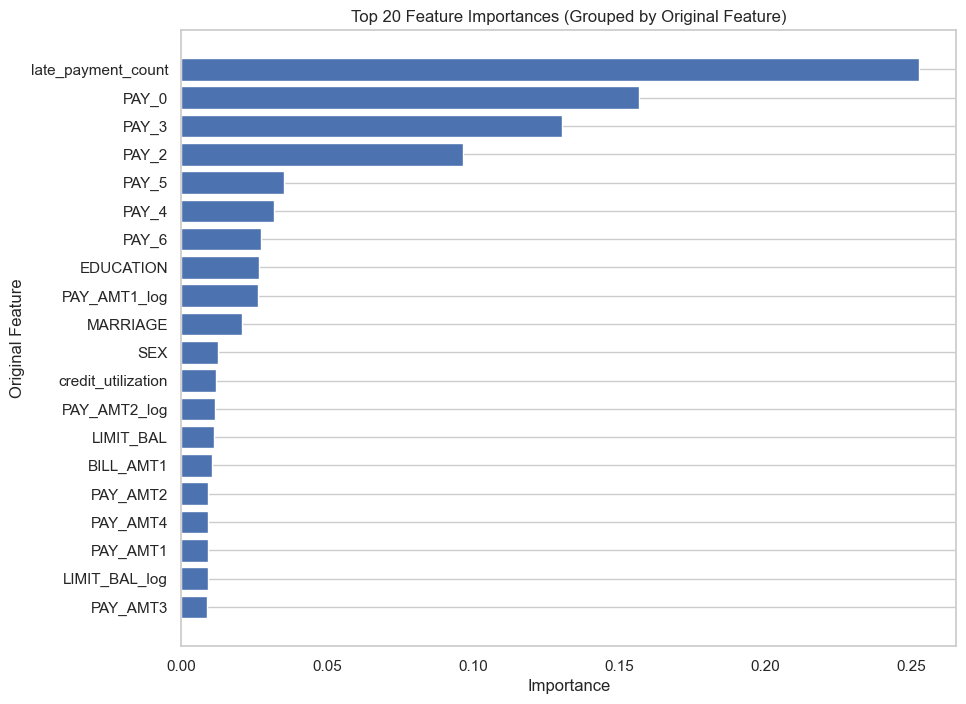

In [95]:
import matplotlib.pyplot as plt

top_n = 20
plot_df = fi_grouped.head(top_n).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(plot_df['feature_original'], plot_df['importance'])
plt.xlabel('Importance')
plt.ylabel('Original Feature')
plt.title(f'Top {top_n} Feature Importances (Grouped by Original Feature)')
plt.grid(axis='x')
plt.show()

1. 모델 직렬화 > pipeline 객체로 직렬화
2. 프로젝트 환경구성  > ml_edu 가상환경에 streamlit 설치해서 진행하기로 정함.
3. 추론 파이프라인 구축
4. 스트림릿   설계및 구현
5. 웹화면에서 예측 테스트